In [ ]:
import sys; sys.path += ['./../']
import numpy as np
from CardamomOT import train_classifier, predict_cell_types, plot_cell_type_proportions
import anndata as ad
import matplotlib.pyplot as plt
import os
import pandas as pd

label="cell_type"

# Name of the file where are the data
p_DO = './../experimental_datasets/Kameneva/'
p_S =  './../experimental_datasets/Schiebinger/'
p_Sem = "./../experimental_datasets/Semrau/"

def compare_cell_types(p, perturb_name, split='train', stim=1.0, prior=1.0):
    """
    Compare les types cellulaires avant/après une perturbation combinée (KO/OV).
    `perturb_name` peut être un label de type:
      - "KO_HSPA1B_OV_0"
      - "combo_1_KO_HSPA1B-COL64A2_OV_HSPA1B"
    """

    # --- Chargement des données principales
    adata_full = ad.read_h5ad(os.path.join(p, 'Data', f'data_{split}.h5ad'))

    adata_train = ad.read_h5ad(os.path.join(p, f'cardamomOT/adata_rna_traj_stim{stim}_prior{prior}.h5ad'))
    adata_sim = ad.read_h5ad(os.path.join(p, f'cardamomOT/adata_sim_stim{stim}_prior{prior}.h5ad'))

    # --- Chargement de la simulation combinée
    adata_perturb_path = os.path.join(
        p, f'cardamomOT/adata_sim_{perturb_name}_stim{stim}_prior{prior}.h5ad'
    )

    if not os.path.exists(adata_perturb_path):
        raise FileNotFoundError(f"⚠️ Fichier {adata_perturb_path} introuvable.")
    
    adata_perturb = ad.read_h5ad(adata_perturb_path)
    print(f"📂 Lecture : {adata_perturb_path}")

    # --- Entraînement du classifieur sur les données réelles
    clf = train_classifier(adata_full, label_key=label)
    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_sim = predict_cell_types(adata_sim, clf, label_key=label)

    # --- Identifier les gènes à modifier
    # Exemple : "combo_1_KO_HSPA1B-COL64A2_OV_HSPA1B"
    name_parts = perturb_name.split('_')
    ko_genes, ov_genes = [], []

    if "KO" in name_parts:
        ko_idx = name_parts.index("KO")
        # tout jusqu’à OV ou fin
        for g in name_parts[ko_idx + 1:]:
            if g == "OV": break
            if g not in ["none", "0"]:
                ko_genes.extend(g.split('-'))

    if "OV" in name_parts:
        ov_idx = name_parts.index("OV")
        for g in name_parts[ov_idx + 1:]:
            if g not in ["none", "0"]:
                ov_genes.extend(g.split('-'))

    perturbed_genes = list(set(ko_genes + ov_genes))
    print(f"🧬 Gènes perturbés détectés : {perturbed_genes}")

    # --- Créer une version "simulée modifiée"
    adata_sim_modif = adata_sim.copy()

    for gene in perturbed_genes:
        if gene not in adata_full.var_names:
            print(f"⚠️ Gène {gene} introuvable dans adata_full, ignoré.")
            continue

        cnt = np.where(adata_full.var_names == gene)[0][0]
        print(f"🔄 Remplacement des valeurs simulées pour {gene}")
        print(f"Avant : mean={np.mean(adata_sim_modif.X[:, cnt]):.3f}, Après : mean={np.mean(adata_perturb.X[:, cnt]):.3f}")
        adata_sim_modif.X[:, cnt] = adata_perturb.X[:, cnt]

    # --- Prédictions des types cellulaires
    adata_sim_modif = predict_cell_types(adata_sim_modif, clf, label_key=label)
    adata_perturb = predict_cell_types(adata_perturb, clf, label_key=label)

    adata_perturb.write(p+f'cardamomOT/adata_sim_{perturb_name}_stim{stim}_prior{prior}.h5ad')

    cmap_cat = plt.get_cmap('Dark2')
    cats = adata_full.obs["cell_type"].astype(str).unique().tolist()
    colors = [cmap_cat(i % 20) for i in range(len(cats))]

    # --- Visualisation
    prop_df = plot_cell_type_proportions(
        adatas=[adata_train, adata_sim, adata_sim_modif, adata_perturb],
        labels=["data", "sim wt", "sim single", "sim perturb"],
        label_key=label, colors=colors
    )
    prop_df.to_csv('prop_df', index=False)

📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_CHGA_OV_STMN2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['CHGA', 'STMN2']
🔄 Remplacement des valeurs simulées pour CHGA
Avant : mean=24.784, Après : mean=0.421
🔄 Remplacement des valeurs simulées pour STMN2
Avant : mean=13.978, Après : mean=33.157


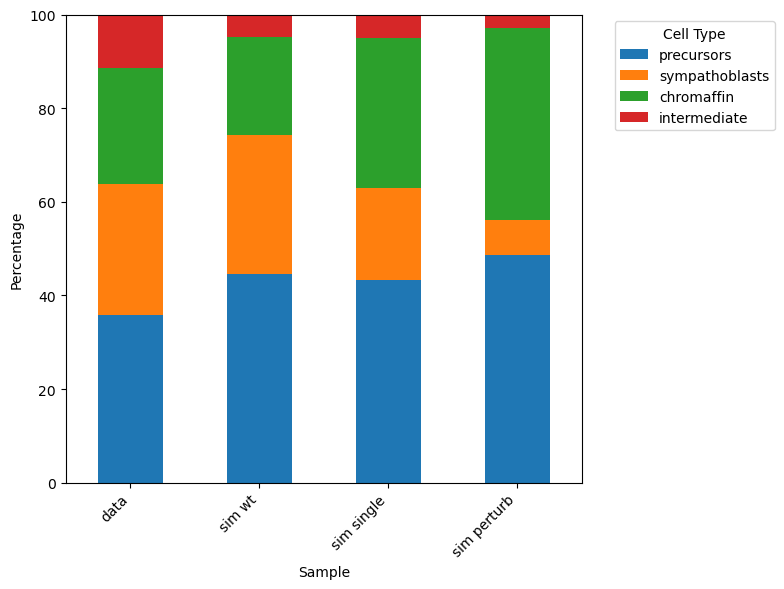

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        44.611111       29.611111   20.888889      4.888889
sim single    43.388889       19.444444   32.166667      5.000000
sim perturb   48.611111        7.500000   41.055556      2.833333
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_CHGA_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['CHGA']
🔄 Remplacement des valeurs simulées pour CHGA
Avant : mean=24.784, Après : mean=0.435


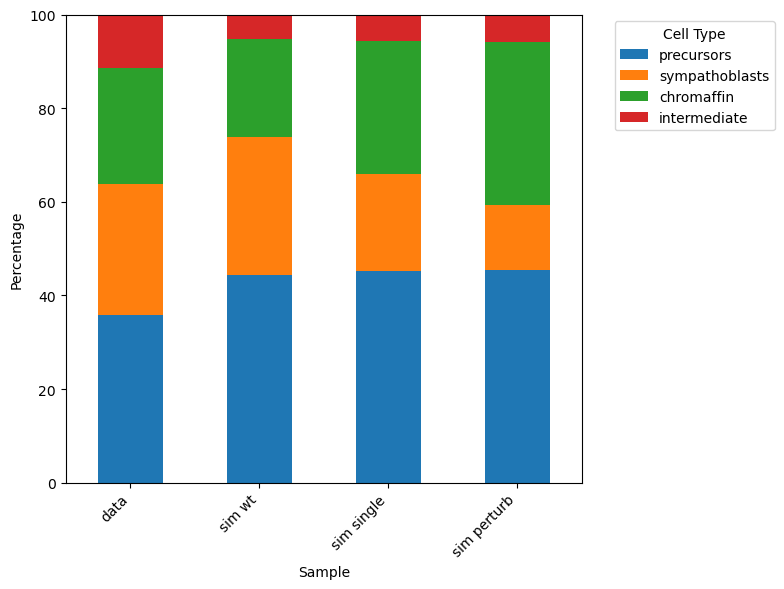

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        44.388889       29.444444   21.000000      5.166667
sim single    45.166667       20.833333   28.333333      5.666667
sim perturb   45.444444       13.833333   34.944444      5.777778
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_none_OV_STMN2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['STMN2']
🔄 Remplacement des valeurs simulées pour STMN2
Avant : mean=13.978, Après : mean=33.372


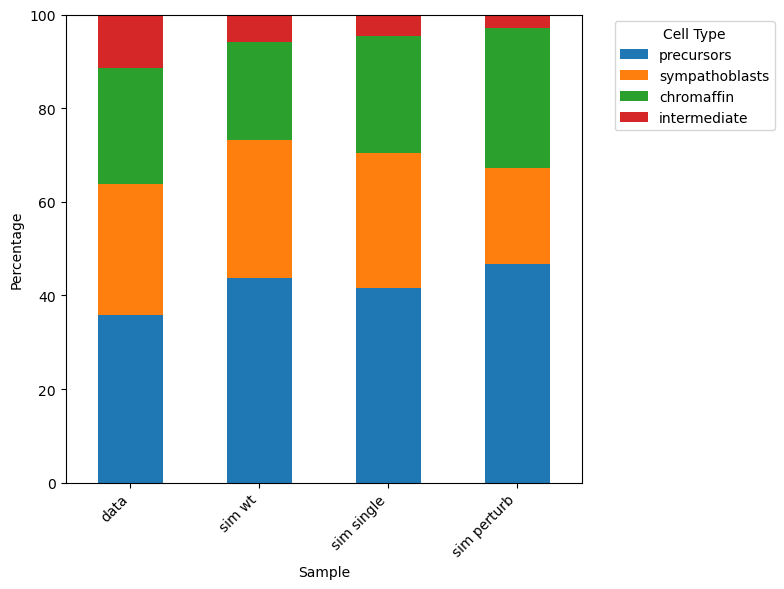

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        43.666667       29.555556   20.833333      5.944444
sim single    41.500000       28.833333   25.000000      4.666667
sim perturb   46.777778       20.500000   29.777778      2.944444
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_none_OV_S100B_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['S100B']
🔄 Remplacement des valeurs simulées pour S100B
Avant : mean=4.099, Après : mean=21.255


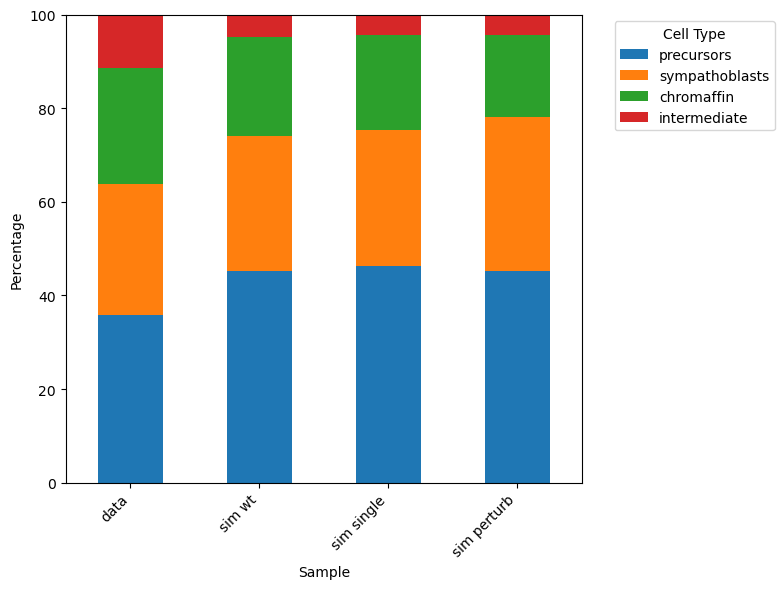

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        45.166667       28.777778   21.333333      4.722222
sim single    46.277778       29.055556   20.333333      4.333333
sim perturb   45.277778       32.722222   17.611111      4.388889
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_none_OV_POSTN_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['POSTN']
🔄 Remplacement des valeurs simulées pour POSTN
Avant : mean=3.297, Après : mean=5.649


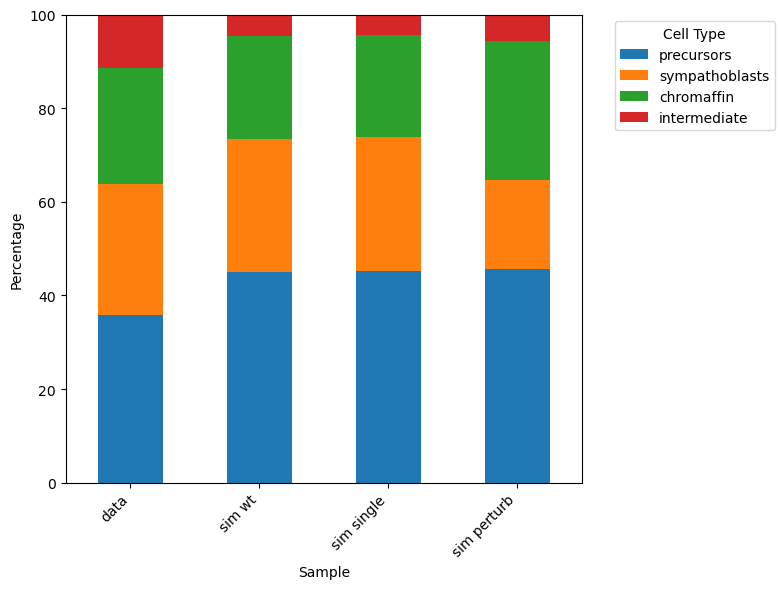

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        44.944444       28.555556   22.000000      4.500000
sim single    45.166667       28.722222   21.777778      4.333333
sim perturb   45.611111       19.055556   29.611111      5.722222
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_POSTN_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['POSTN']
🔄 Remplacement des valeurs simulées pour POSTN
Avant : mean=3.297, Après : mean=0.509


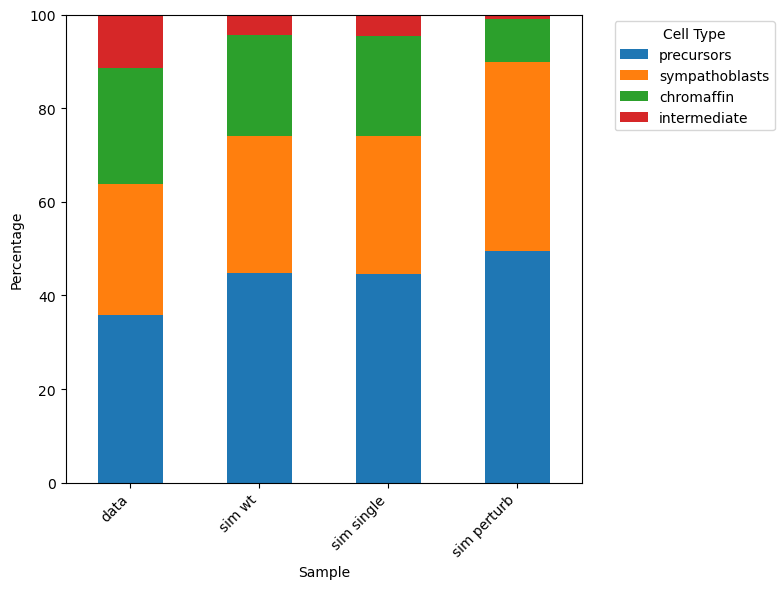

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        44.777778       29.333333   21.555556      4.333333
sim single    44.611111       29.388889   21.500000      4.500000
sim perturb   49.444444       40.444444    9.166667      0.944444


In [6]:
compare_cell_types(p_DO,"KO_CHGA_OV_STMN2", split='full')
compare_cell_types(p_DO,"KO_CHGA_OV_none", split='full')
compare_cell_types(p_DO,"KO_none_OV_STMN2", split='full')
compare_cell_types(p_DO,"KO_none_OV_S100B", split='full')
compare_cell_types(p_DO,"KO_none_OV_POSTN", split='full')
compare_cell_types(p_DO,"KO_POSTN_OV_none", split='full')

In [9]:
compare_cell_types(p_Sem,"KO_none_OV_Zfp42", split='full')
compare_cell_types(p_Sem,"KO_none_OV_Sox2", split='full')
compare_cell_types(p_Sem,"KO_none_OV_Jarid2", split='full')
compare_cell_types(p_Sem,"KO_none_OV_Hoxb2", split='full')
compare_cell_types(p_Sem,"KO_none_OV_Dnmt3a", split='full')
compare_cell_types(p_Sem,"KO_none_OV_Col4a2", split='full')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './../experimental_datasets/Semrau/Data/data_train.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

📂 Lecture : ./../collaborations/Schiebinger/cardamomOT/adata_sim_KO_none_OV_Obox6-Zfp42_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Obox6', 'Zfp42']
🔄 Remplacement des valeurs simulées pour Obox6
Avant : mean=0.562, Après : mean=2.337
🔄 Remplacement des valeurs simulées pour Zfp42
Avant : mean=0.648, Après : mean=2.626


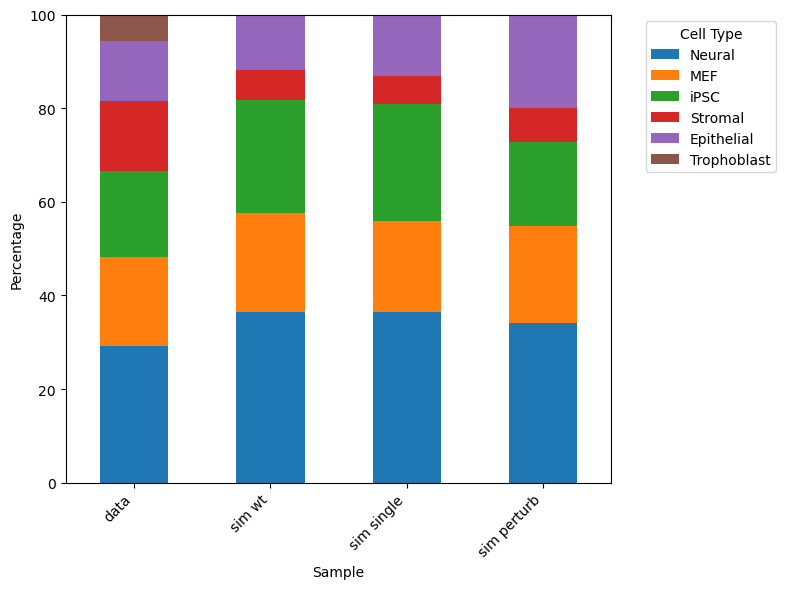

cell_type       Neural        MEF       iPSC    Stromal  Epithelial  \
data         29.168033  19.025765  18.337376  14.980660   12.922048   
sim wt       36.381186  21.310109  24.034749   6.467181   11.530362   
sim single   36.359249  19.559495  24.969287   5.923131   13.013338   
sim perturb  34.082134  20.818708  17.804493   7.410495   19.783257   

cell_type    Trophoblast  
data            5.566118  
sim wt          0.276413  
sim single      0.175500  
sim perturb     0.100913  
📂 Lecture : ./../collaborations/Schiebinger/cardamomOT/adata_sim_KO_none_OV_Obox6_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Obox6']
🔄 Remplacement des valeurs simulées pour Obox6
Avant : mean=0.562, Après : mean=2.329


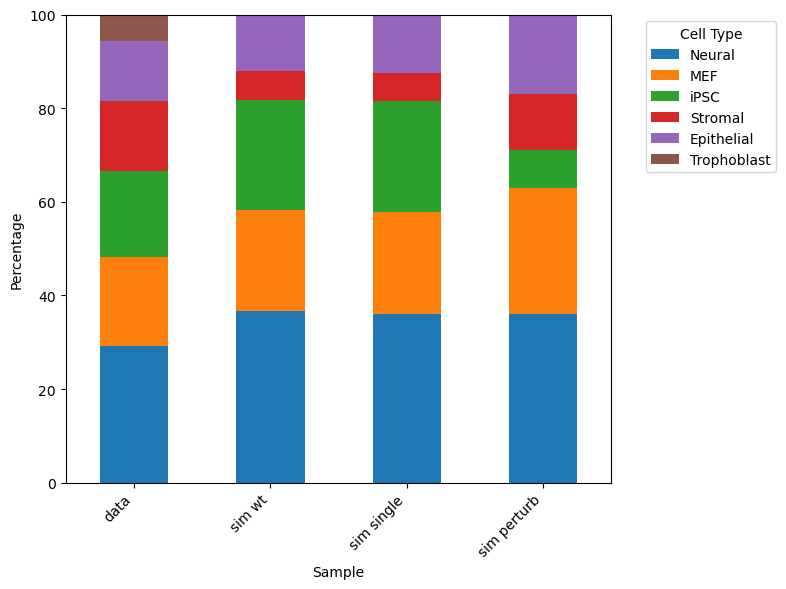

cell_type       Neural        MEF       iPSC    Stromal  Epithelial  \
data         29.168033  19.025765  18.337376  14.980660   12.922048   
sim wt       36.596174  21.608459  23.604774   6.173219   11.679537   
sim single   35.977536  21.735697  23.736399   6.160056   12.048087   
sim perturb  36.082836  26.816427   8.252896  11.960337   16.580379   

cell_type    Trophoblast  
data            5.566118  
sim wt          0.337838  
sim single      0.342225  
sim perturb     0.307125  
📂 Lecture : ./../collaborations/Schiebinger/cardamomOT/adata_sim_KO_none_OV_Zfp42_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Zfp42']
🔄 Remplacement des valeurs simulées pour Zfp42
Avant : mean=0.648, Après : mean=2.654


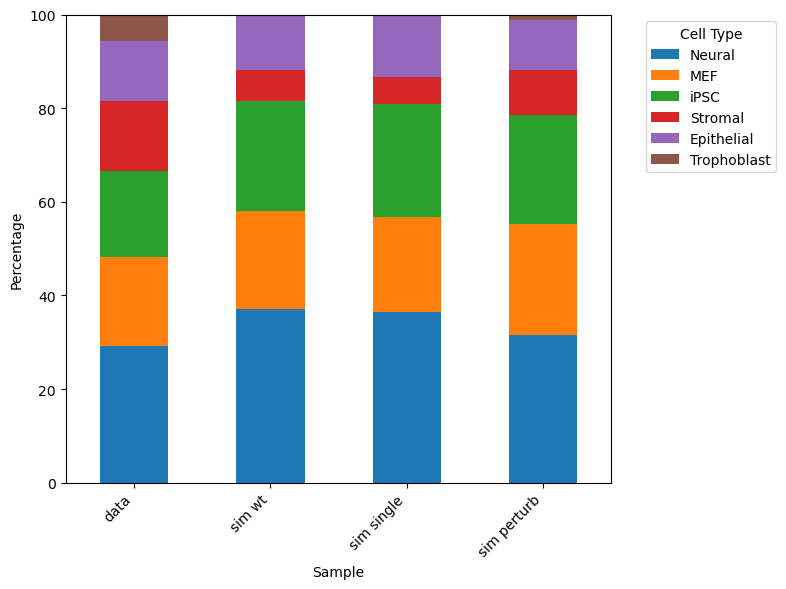

cell_type       Neural        MEF       iPSC    Stromal  Epithelial  \
data         29.168033  19.025765  18.337376  14.980660   12.922048   
sim wt       37.096350  20.941558  23.582836   6.550544   11.521587   
sim single   36.438224  20.217620  24.201474   5.852931   13.044051   
sim perturb  31.445244  23.797824  23.323973   9.542822   10.780098   

cell_type    Trophoblast  
data            5.566118  
sim wt          0.307125  
sim single      0.245700  
sim perturb     1.110039  


In [ ]:
compare_cell_types(p_S,"KO_none_OV_Obox6-Zfp42")
compare_cell_types(p_S,"KO_none_OV_Obox6")
compare_cell_types(p_S,"KO_none_OV_Zfp42")